# 03 · Model Training + Results

**When to run this notebook:** whenever you add or change a model, to produce a
full training run across all model families and evaluate it on the locked
holdout.

## Business framing

We are solving a **supervised binary classification** problem: will a video beat
its channel's own 7-day median engagement, using only upload/24h signals? The
target is naturally ~50/50 by design, so the comparison across models is about
ranking quality and error trade-offs, not class imbalance.

This notebook:
1. trains **all** model families on the most recent committed data snapshot
   (Logistic Regression L1, Random Forest, XGBoost, and an RF+XGB ensemble);
2. analyzes the train / test / validation splits;
3. evaluates on the **locked validation holdout** and compares train/test/val;
4. runs a **segment audit** to surface per-vertical / per-tier blind spots;
5. places the run in the context of the full model-version history.

> **Sequence:** notebook 3 of 5. See [notebooks.md](./notebooks.md).

## Configuration

A single **`RUN_MODE`** switch selects the scenario (it replaces the `IS_DRY_RUN`
flag the other notebooks use, because this notebook has three distinct run modes
rather than a simple write/no-write toggle):

- **`"OLD_MODEL_OLD_DATA"`** (default) — reuse the most recent committed snapshot
  from GCS (*no BigQuery call*) and **view results only**; nothing is written and
  no images are saved.
- **`"OLD_MODEL_OLD_DATA_NEW_PICS"`** — same as above (dry run, no GCS writes),
  but **saves images** to disk. Use this after notebook 04 bumps the model version
  — the retrained models produce new plots but you don't want another version bump.
- **`"NEW_MODEL_OLD_DATA"`** — reuse the committed snapshot but **persist** the
  retrained models (model minor version bump). Use when a model changed.
- **`"NEW_DATA"`** — pull a fresh snapshot from BigQuery, retrain, and persist
  everything (data minor bump + baselines + model **major** bump).

The load / preprocess / train / evaluate steps below are **identical** across all
four modes — only the config above differs.

In [1]:
import sys
import os

# Make the capstone package importable (notebook lives in notebooks/, code in src/capstone/).
sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pipeline.version_config import VersionConfig
from pipeline.pipeline_run import PipelineRun
from pipeline.factory import PipelineFactory
from pipeline.stages import eda
from utils.snapshot_model import ModelResult, ModelType
from evaluation.segment_auditor import SegmentAuditor
from dataclasses import asdict

IMAGES_FOLDER = "../../../images/results/"

# Single run-mode selector for this notebook. The four scenarios here are not a
# simple write/no-write toggle, so RUN_MODE replaces the IS_DRY_RUN flag the other
# notebooks use:
#   "OLD_MODEL_OLD_DATA"          -> reuse committed snapshot, no writes, no images
#   "OLD_MODEL_OLD_DATA_NEW_PICS" -> reuse committed snapshot, no GCS writes, save images
#   "NEW_MODEL_OLD_DATA"          -> reuse committed snapshot, persist model snapshot + minor bump
#   "NEW_DATA"                    -> BQ pull + retrain, persist everything (data minor + model MAJOR bump)
#
# Default writes new images and NO data: reuse the committed snapshot and save figures.
RUN_MODE = "OLD_MODEL_OLD_DATA_NEW_PICS"

# Preserve this run in GCS so it can be compared against later, even if the tier
# models are dropped. Writes to a dedicated experiments/tier_split/ namespace —
# NOT the canonical models/ lineage. Kept False so this run writes no data.
SAVE_TIER_EXPERIMENT = False


# Figures are saved on persisting runs and in NEW_PICS mode; skipped in plain OLD_MODEL_OLD_DATA.
def fig_path(name):
    if RUN_MODE == "OLD_MODEL_OLD_DATA":
        return None
    return f"{IMAGES_FOLDER}{name}"

# Metric column order used in every results table below. Global (macro) metrics
# come first, then the per-class above/below breakdown.
#   *_macro = sklearn average="macro" = unweighted mean of above- and below-baseline
#             scores. It is the single "overall" number that weights both classes equally.
METRIC_COLS = [
    "roc_auc", "accuracy",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_above", "recall_above", "f1_above",
    "precision_below", "recall_below", "f1_below",
]

In [2]:
if RUN_MODE == "NEW_DATA":
    # Fresh BQ pull. Persists a data minor bump (+ baselines), the engineered
    # splits, and a model MAJOR bump (retrained on new data). Always a real run —
    # a data pull is never previewed.
    config = (
        VersionConfig.load(use_synthetic=False)
        .snapshot_raw()
        .snapshot_final()
        .snapshot_models_new_data()
        .dry_run(False)
        .build()
    )
    stages = PipelineFactory.full_run(config)
elif RUN_MODE in ("NEW_MODEL_OLD_DATA", "OLD_MODEL_OLD_DATA", "OLD_MODEL_OLD_DATA_NEW_PICS"):
    # Reuse the latest committed snapshot (no BQ). snapshot_models() is chained
    # unconditionally; dry_run() decides whether the model minor bump persists —
    # NEW_MODEL_OLD_DATA persists it, the OLD_* modes are view-only dry runs.
    config = (
        VersionConfig.load(use_synthetic=False)
        .snapshot_models()
        .dry_run(RUN_MODE in ("OLD_MODEL_OLD_DATA", "OLD_MODEL_OLD_DATA_NEW_PICS"))
        .build()
    )
    stages = PipelineFactory.retrain_existing_data(config)
else:
    raise ValueError(
        f"Unknown RUN_MODE {RUN_MODE!r}. Use one of: "
        "'OLD_MODEL_OLD_DATA', 'OLD_MODEL_OLD_DATA_NEW_PICS', 'NEW_MODEL_OLD_DATA', 'NEW_DATA'."
    )

run = PipelineRun(config)
print("Scenario:", stages.scenario, "| RUN_MODE:", RUN_MODE)

VersionConfig loaded:
  data:          v3.5 (raw_suffix='real')
  baselines:     v5.0
  model:         v6.2
  hyperparams:   v1.2
  use_synthetic: False

VersionConfig ready:
  Active flags      : ['none (dry run)']
  data              : v3.5 (unchanged)
  baselines         : v5.0 (unchanged)
  model             : v6.2 (unchanged)
  hyperparams       : v1.2 (unchanged)
  raw_version       : v3.5_real
  next_final_version: v3.5_100real
  model_version     : v6.2
  baselines_version : v5.0
  hyperparam_version: v1.2
  use_synthetic     : False
  dry_run           : True  (no GCS writes will occur)

  DRY RUN — set .dry_run(False) to persist artifacts and commit versions.


Scenario: retrain_existing_data | RUN_MODE: OLD_MODEL_OLD_DATA_NEW_PICS


### Pipeline execution — through scaling

The stage calls below are the same regardless of the run mode. In the
`OLD_MODEL_OLD_DATA` / `NEW_MODEL_OLD_DATA` modes `RawSnapshotter` is a no-op; in
the `NEW_DATA` mode it writes the fresh raw snapshot.

In [3]:
stages.loader.run(run)
stages.raw_snapshotter.run(run)   # writes only in the NEW_DATA scenario
stages.preprocessor.run(run)
stages.engineer.run(run)
stages.splitter.run(run)
stages.scaler.run(run)
run.summary()

Loaded snapshot 'v3.5_real': 106626 rows from 2026-05-29
  Polls: {'upload': 37387, '24h': 36506, '7d': 32733}


Loaded baselines 'v5.0': 40841 baseline videos, 1375 median rows (1375 channels)
[dry_run] RawSnapshotter — GCS write skipped.
Building clean dataset
snapshot cols: Index(['video_id', 'poll_timestamp', 'channel_id', 'channel_handle', 'title',
       'view_count', 'like_count', 'comment_count', 'face_count', 'brightness',
       'colorfulness', 'vertical', 'tier', 'description', 'tags',
       'duration_seconds', 'category_id', 'category_name', 'published_at',
       'poll_label', 'hours_since_publish', 'subscriber_count',
       'contains_synthetic_media'],
      dtype='object')

[1/3] Pivoting snapshots...
  Videos with all 3 polls: 32571 (dropped 4864 incomplete)
  Pivoted shape: (32740, 34)

[2/3] Joining baseline medians...
  Baseline join: 32740/32740 videos matched a channel median

[3/3] Cleaning data...


  Dropped 15 row(s) with null contains_synthetic_media (private/failed harvest).
  Cleaned: 32725 rows × 40 columns

Clean dataset: 32725 rows × 40 columns
  all: dropped 599 rows with NaN in a baseline_median_* column or 0.0 baseline_median_engagement_rate
Engineering features

[1/10] Computing target variable...
  Target distribution: 54.9% above baseline, 45.1% below

[2/10] Computing velocity features...
  Computed velocity, upload momentum, normalized velocity, and acceleration features

[3/10] Computing ratio and baseline-normalized features...
  Computed ratio and baseline-normalized features

[4/10] Computing subscriber-normalized metrics...
  Computed subscriber-normalized metrics for upload/24h/7d

[5/10] Computing categorical features...


  Title categories:
title_category
neutral        20050
all_caps        3752
exclamation     3455
question        2932
listicle        1054
how_to           408
clickbait        356
emoji_heavy      119
  Description categories:
desc_category
link_heavy        8772
minimal           7616
has_links         6764
has_hashtags      4788
neutral           2681
has_timestamps    1439
long_form           66

[6/10] Computing text structural features...
  Computed text structural features

[7/10] Computing temporal features...
  Computed temporal features

[8/10] Computing duration features...
  Computed duration features

[9/10] Computing thumbnail features...
  Computed thumbnail features

[10/10] Computing interaction features...
  Computed is_short interaction features

Modeling table: 32126 rows × 85 columns
Target balance: {1: 17628, 0: 14498}


DataSplitter — loaded holdout (5,192 val rows):
  df_val:    5,192 rows (17.5%)
  df_train: 19,589 rows (66.0%)
  df_test:   4,898 rows (16.5%)
DataSplitter — gen split: 2,447 rows (Music/Sports, grows over time)
  Music_L: 78
  Music_M: 255
  Music_S: 236
  Sports_L: 484
  Sports_M: 574
  Sports_S: 820
PipelineRun(config=VersionConfig(data=(3, 5), model=(6, 2), baselines=(5, 0), hyperparams=(1, 2), use_synthetic=False, active=['models']))
  df_videos      populated  DataFrame shape=(106626, 23)
  df_baselines   populated  DataFrame shape=(40841, 15)
  df_medians     populated  DataFrame shape=(1375, 7)
  df_clean       populated  DataFrame shape=(32725, 40)
  df_engineered  populated  DataFrame shape=(32126, 89)
  df_train       populated  DataFrame shape=(19589, 89)
  df_test        populated  DataFrame shape=(4898, 89)
  df_val         populated  DataFrame shape=(5192, 89)
  df_gen         populated  DataFrame shape=(2447, 89)
  X_train        populated  DataFrame shape=(19589, 55)


## Analysis of the train / test / validation sets

Before training, confirm the three partitions are representative. The validation
holdout is **locked** (fixed video IDs in GCS); train/test are re-split 80/20
from the remaining pool on each run, stratified on the 18-cell key so class
balance and segment mix stay consistent across splits.

In [4]:
# Sizes and class balance per split.
split_rows = []
for name, dfs in [("train", run.df_train), ("test", run.df_test), ("val", run.df_val)]:
    split_rows.append({
        "split": name,
        "rows": len(dfs),
        "pct_of_total": round(len(dfs) / (len(run.df_train) + len(run.df_test) + len(run.df_val)) * 100, 1),
        "pct_above_baseline": round(dfs["above_baseline"].mean(), 3),
    })
df_splits = pd.DataFrame(split_rows).set_index("split")
print(df_splits.to_string())

        rows  pct_of_total  pct_above_baseline
split                                         
train  19589          66.0               0.553
test    4898          16.5               0.553
val     5192          17.5               0.555


Vertical share by split:
           train   test    val
vertical                      
Tech       0.345  0.344  0.189
Lifestyle  0.338  0.338  0.637
Education  0.318  0.318  0.174


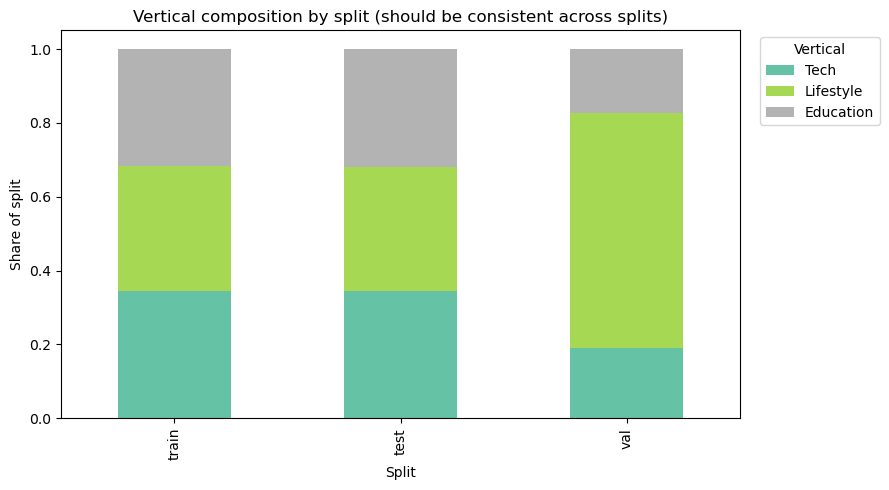

In [5]:
# Segment representation across splits (vertical x tier), merged back from df_clean.
labels = run.df_clean[["video_id", "vertical", "tier"]]
seg_frames = []
for name, dfs in [("train", run.df_train), ("test", run.df_test), ("val", run.df_val)]:
    merged = dfs[["video_id"]].merge(labels, on="video_id", how="left")
    share = merged["vertical"].value_counts(normalize=True).rename(name)
    seg_frames.append(share)
df_vertical_mix = pd.concat(seg_frames, axis=1).round(3)
print("Vertical share by split:")
print(df_vertical_mix.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
df_vertical_mix.T.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")
ax.set_title("Vertical composition by split (should be consistent across splits)")
ax.set_ylabel("Share of split")
ax.set_xlabel("Split")
ax.legend(title="Vertical", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
split_fig = fig_path("03_split_vertical_mix.png")
if split_fig:
    plt.savefig(split_fig)
plt.show()

## Train all models

`ModelTrainer` trains Logistic Regression (L1), Random Forest, XGBoost, LightGBM,
MLP, and the soft-voting RF+XGB ensemble using the hyperparameters from the
current GCS snapshot, then evaluates each on the **test** split. Hyperparameter
search is *not* run here — that is the job of notebook 04. Cross-validation
underlies the tuned parameters loaded from the hyperparameter snapshot.

In [6]:
stages.trainer.run(run)
print(f"Total training time: {run.train_elapsed_s:.1f}s")
run.summary()

Loaded hyperparams 'v1.2' (saved 2026-05-30)
  Models: ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'MLP', 'VotingClassifier', 'StackingClassifier']
  Search: {'strategy': 'random', 'n_iter': 100, 'cv': 5, 'scoring': 'roc_auc'}
Loaded hyperparams from snapshot 'v1.2'.
  Note: injected l1_ratio=0.5 for elasticnet LR (missing from snapshot).
Training LogisticRegression (L1)...


Training RandomForestClassifier...


Training XGBClassifier...


Training LGBMClassifier...


Training MLPClassifier...


Training VotingClassifier ensemble (RF + XGB, soft vote, weights=[1, 2])...


Training StackingClassifier (RF + XGB + LGB → LR, 5-fold CV)...



=== ModelTrainer — test-set results ===
  lr_l1               AUC=0.7792  acc=0.7129  F1↑=0.7479
  rf                  AUC=0.8922  acc=0.8122  F1↑=0.8384
  xgb                 AUC=0.9274  acc=0.8501  F1↑=0.8662
  lgb                 AUC=0.9234  acc=0.8471  F1↑=0.8640
  mlp                 AUC=0.8651  acc=0.7889  F1↑=0.8123
  ensemble_voting     AUC=0.9244  acc=0.8483  F1↑=0.8657
  ensemble_stacking   AUC=0.9270  acc=0.8508  F1↑=0.8668
Total training time: 302.0s
PipelineRun(config=VersionConfig(data=(3, 5), model=(6, 2), baselines=(5, 0), hyperparams=(1, 2), use_synthetic=False, active=['models']))
  df_videos      populated  DataFrame shape=(106626, 23)
  df_baselines   populated  DataFrame shape=(40841, 15)
  df_medians     populated  DataFrame shape=(1375, 7)
  df_clean       populated  DataFrame shape=(32725, 40)
  df_engineered  populated  DataFrame shape=(32126, 89)
  df_train       populated  DataFrame shape=(19589, 89)
  df_test        populated  DataFrame shape=(4898, 89)
  d

### (Optional) persist artifacts

In the persisting modes, snapshot the engineered splits and the trained models to
GCS. `FinalSnapshotter` writes only in `NEW_DATA` (engineered splits change with
new data); `ModelSnapshotter` writes in both `NEW_MODEL_OLD_DATA` and `NEW_DATA`.
Both are no-ops in `OLD_MODEL_OLD_DATA`.

In [7]:
stages.final_snapshotter.run(run)
stages.model_snapshotter.run(run)

[dry_run] FinalSnapshotter — GCS write skipped.
[dry_run] ModelSnapshotter — GCS write skipped.


PipelineRun(model_version='v6.2', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models'])

## Evaluate on the locked validation holdout

`Validator` scores each model on the locked holdout using each model's own saved
scaler, then `ValidationResultsSnapshotter` appends the run to the JSONL history
(skipped in `OLD_MODEL_OLD_DATA`; written in the persisting modes).

In [8]:
stages.validator.run(run)
stages.validation_results_snapshotter.run(run)


=== Validator — validation-set results ===
  lr_l1           AUC=0.7679  acc=0.7036  F1↑=0.7384
  rf              AUC=0.8861  acc=0.8062  F1↑=0.8332
  xgb             AUC=0.9200  acc=0.8432  F1↑=0.8606
  lgb             AUC=0.9188  acc=0.8442  F1↑=0.8619
  mlp             AUC=0.8503  acc=0.7735  F1↑=0.7972
  ensemble_voting  AUC=0.9169  acc=0.8407  F1↑=0.8591
  ensemble_stacking  AUC=0.9201  acc=0.8428  F1↑=0.8599
[dry_run] ValidationResultsSnapshotter — GCS append skipped.


PipelineRun(model_version='v6.2', num_synth_rows=0, populated=['df_videos', 'df_baselines', 'df_medians', 'df_clean', 'df_engineered', 'df_train', 'df_test', 'df_val', 'df_gen', 'X_train', 'X_test', 'X_val', 'X_val_unscaled', 'X_gen', 'y_train', 'y_test', 'y_val', 'y_gen', 'models', 'results'])

### A note on the evaluation metrics

Every metrics table in this notebook leads with three **global** scores —
`precision_macro`, `recall_macro`, `f1_macro` — followed by the per-class
breakdown (`*_above`, `*_below`).

The global scores use **sklearn's `average="macro"`**: compute precision /
recall / F1 separately for each class, then take the unweighted mean across
classes. For example, `f1_macro = mean(f1_above, f1_below)`. Because the
target is ~50/50 by design, macro and weighted averages are nearly identical
here — macro is preferred because it treats both classes equally regardless
of exact counts, which matches the intent of a balanced binary target.

The per-class split is retained because the error costs differ — a false
"will overperform" prediction has a different business impact than a false
"will underperform" — but the macro scores are shown first as the headline
numbers.

### Evaluation metric — choice & rationale

The **primary metric is ROC-AUC**: it measures how well a model ranks
above-baseline videos above below-baseline ones across *all* thresholds, which
matches the use case (flagging likely under/over-performers early, where the
decision threshold may be tuned later). Because the classes are ~balanced,
**accuracy** is also meaningful, and **macro F1** gives a single
threshold-dependent summary. ROC-AUC is the metric we select models on.

In [9]:
df_val = pd.DataFrame(run.results).T[METRIC_COLS].astype(float).round(4)
df_val.index.name = "model"
df_val.style.highlight_max(color="#d4edda").format("{:.4f}")

,roc_auc,accuracy,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
model,,,,,,,,,,,
lr_l1,0.7679,0.7036,0.6998,0.6974,0.6982,0.7242,0.7531,0.7384,0.6753,0.6417,0.6581
rf,0.8861,0.8062,0.8083,0.7982,0.8011,0.7985,0.8710,0.8332,0.8182,0.7253,0.7689
xgb,0.9200,0.8432,0.8421,0.8397,0.8407,0.8501,0.8714,0.8606,0.8341,0.8081,0.8209
lgb,0.9188,0.8442,0.8434,0.8403,0.8416,0.8490,0.8752,0.8619,0.8378,0.8055,0.8213
mlp,0.8503,0.7735,0.7708,0.7700,0.7703,0.7929,0.8017,0.7972,0.7487,0.7383,0.7435
ensemble_voting,0.9169,0.8407,0.8401,0.8365,0.8379,0.8443,0.8745,0.8591,0.8358,0.7985,0.8168
ensemble_stacking,0.9201,0.8428,0.8415,0.8396,0.8405,0.8515,0.8686,0.8599,0.8316,0.8107,0.8210


## Train vs. test vs. validation

To diagnose overfitting we score every model on the **training** split too, then
compare train / test / validation side by side. A large train→validation gap
means the model is memorizing the training data; a small gap with high
validation AUC is what we want.

The plot below shows ROC-AUC per model with the train−validation gap annotated
above each group (the chosen format: a single AUC-focused grouped bar with gap
labels). The full multi-metric table follows.

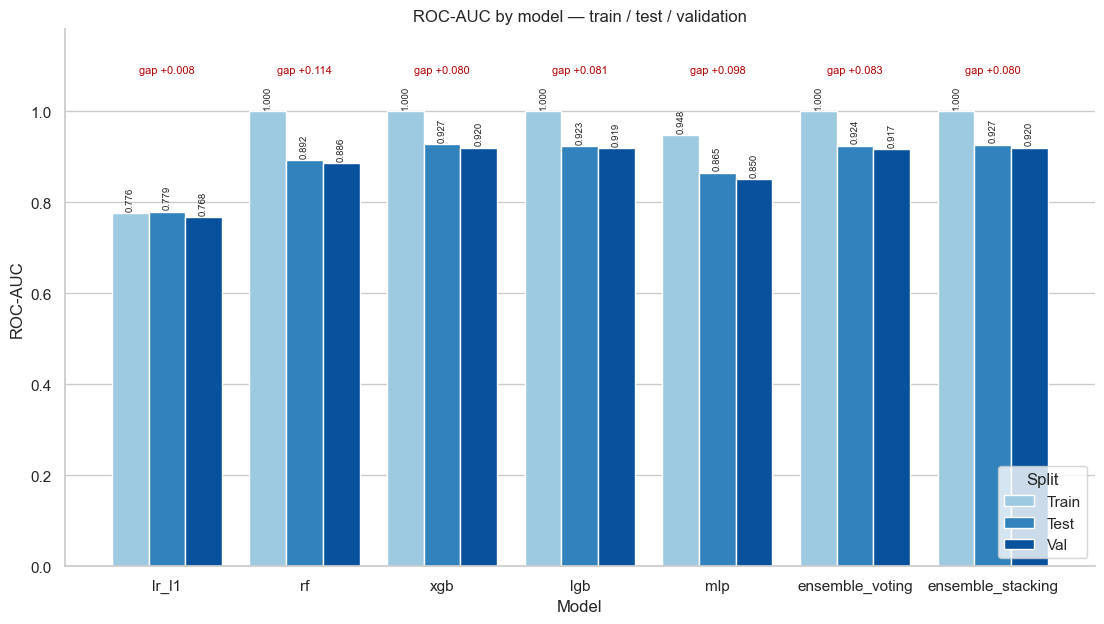

In [10]:
# Score every trained model on the train / test / validation splits.
train_results = {
    name: asdict(ModelResult.from_sklearn(
        entry["model"], run.X_train, run.y_train, run.X_train.columns.tolist()))
    for name, entry in run.models.items()
}
test_results = {name: asdict(entry["result"]) for name, entry in run.models.items()}
val_results = run.results

results_by_split = {"train": train_results, "test": test_results, "val": val_results}

ax = eda.plot_split_comparison(results_by_split, metric="roc_auc")
ax.set_title("ROC-AUC by model — train / test / validation")
ax.set_xlabel("Model")
ax.set_ylabel("ROC-AUC")
eda.save_fig(ax.figure, fig_path("03_train_test_val_auc.png"))
plt.show()

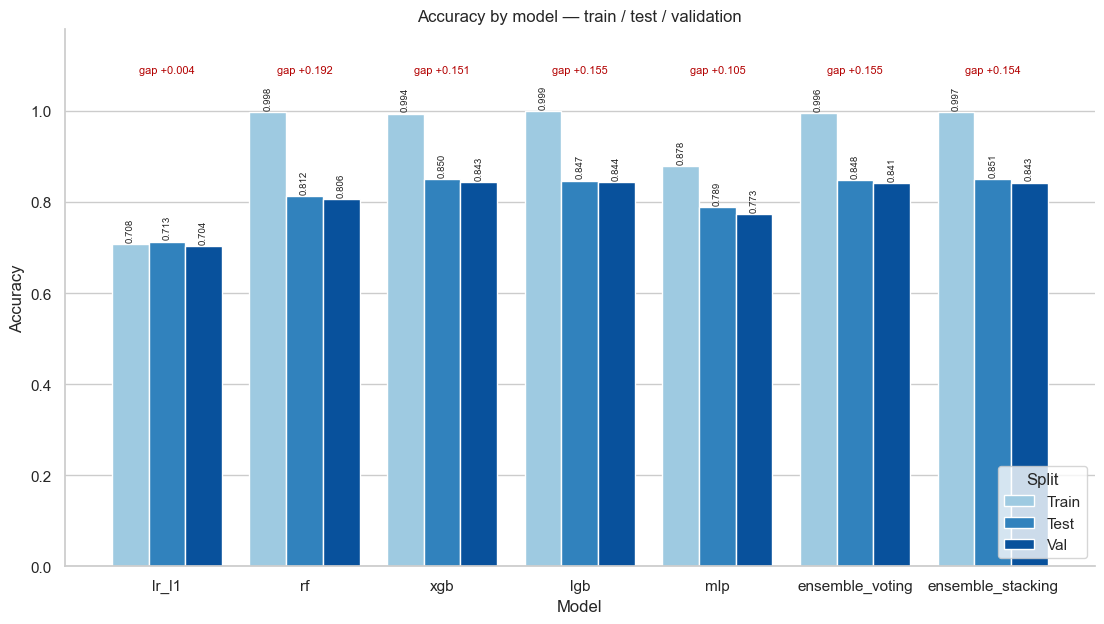

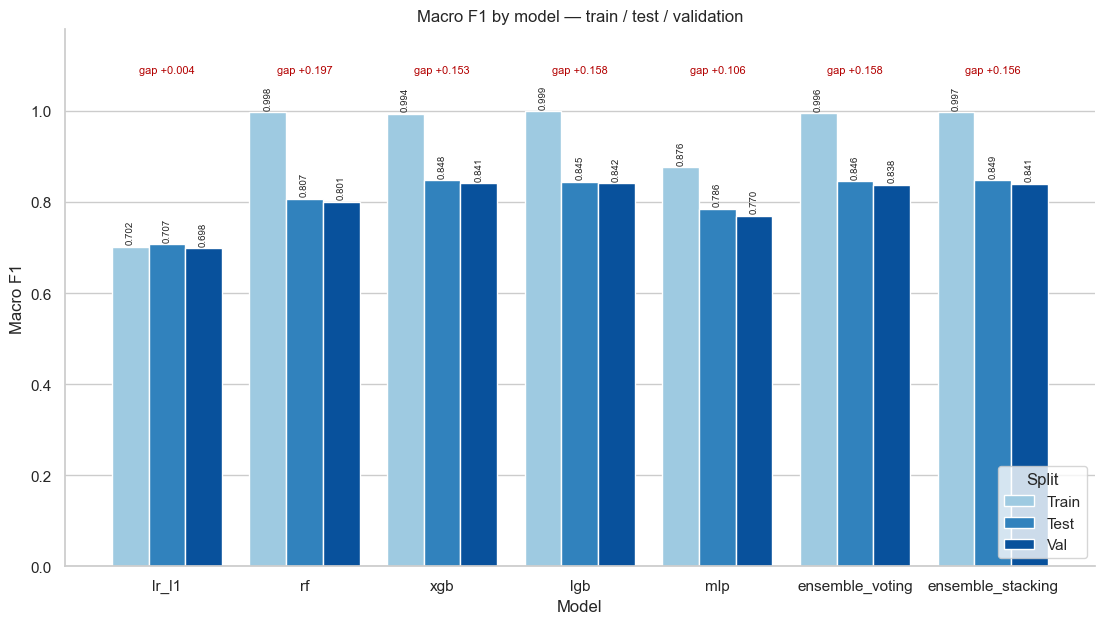

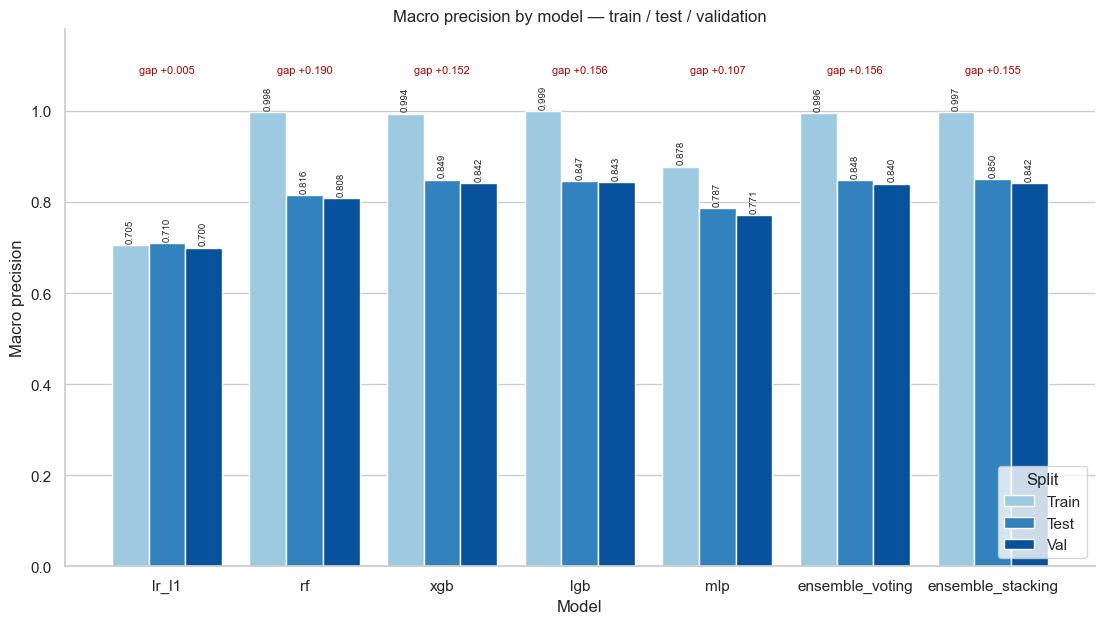

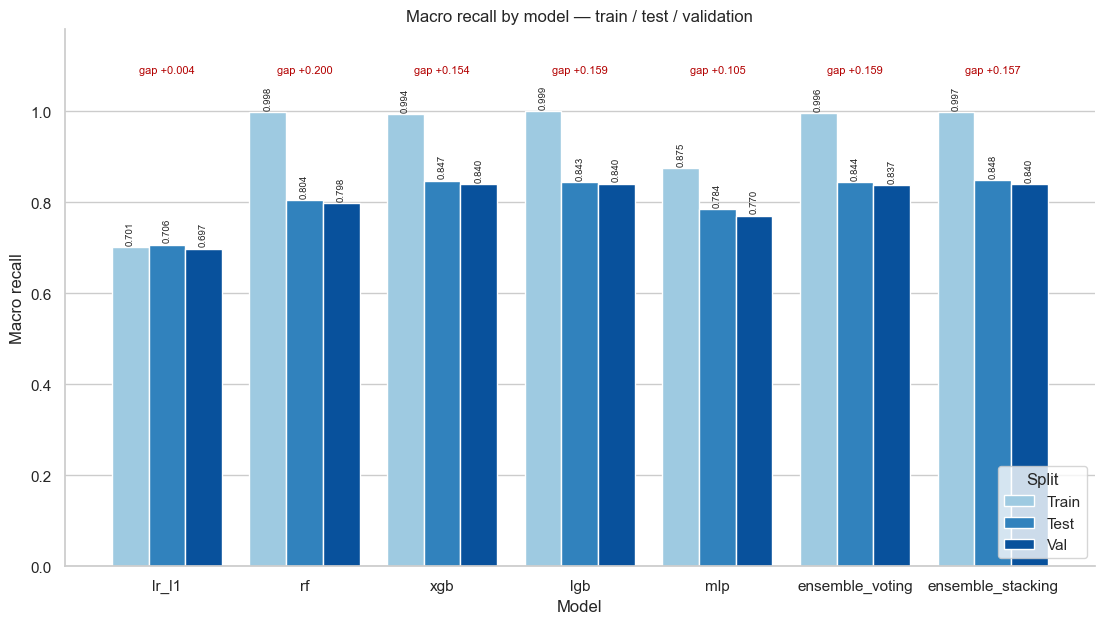

In [11]:
# Accuracy, macro F1, macro Precision, macro Recall — same split view.
metric_labels = {
    "accuracy": "Accuracy",
    "f1_macro": "Macro F1",
    "precision_macro": "Macro precision",
    "recall_macro": "Macro recall",
}
for metric, fname in [
    ("accuracy",        "03_train_test_val_accuracy.png"),
    ("f1_macro",        "03_train_test_val_f1.png"),
    ("precision_macro", "03_train_test_val_precision.png"),
    ("recall_macro",    "03_train_test_val_recall.png"),
]:
    ax = eda.plot_split_comparison(results_by_split, metric=metric)
    ax.set_title(f"{metric_labels[metric]} by model — train / test / validation")
    ax.set_xlabel("Model")
    ax.set_ylabel(metric_labels[metric])
    eda.save_fig(ax.figure, fig_path(fname))
    plt.show()

In [12]:
# Full 3-way table (global macro metrics first, then per-class).
records = {}
for name in run.models:
    records[(name, "train")] = {m: train_results[name].get(m) for m in METRIC_COLS}
    records[(name, "test")] = {m: test_results[name].get(m) for m in METRIC_COLS}
    records[(name, "val")] = {m: val_results[name].get(m) for m in METRIC_COLS}

df_3way = pd.DataFrame(records).T.astype(float).round(4)
df_3way.index.names = ["model", "split"]
df_3way

roc_auc  accuracy  precision_macro  recall_macro  \
model             split                                                     
lr_l1             train   0.7757    0.7077           0.7045        0.7012   
                  test    0.7792    0.7129           0.7100        0.7062   
                  val     0.7679    0.7036           0.6998        0.6974   
rf                train   1.0000    0.9980           0.9980        0.9979   
                  test    0.8922    0.8122           0.8156        0.8040   
                  val     0.8861    0.8062           0.8083        0.7982   
xgb               train   0.9997    0.9940           0.9940        0.9938   
                  test    0.9274    0.8501           0.8492        0.8470   
                  val     0.9200    0.8432           0.8421        0.8397   
lgb               train   1.0000    0.9992           0.9992        0.9993   
                  test    0.9234    0.8471           0.8465        0.8434   
                  val     0.9188    0.8442           0.8434        0.8403   
mlp               train   0.9483    0.8781           0.8780        0.8751   
                  test    0.8651    0.7889           0.7871        0.7845   
                  val     0.8503    0.7735           0.7708        0.7700   
ensemble_voting   train   0.9999    0.9957           0.9957        0.9955   
                  test    0.9244    0.8483           0.8482        0.8441   
                  val     0.9169    0.8407           0.8401        0.8365   
ensemble_stacking train   0.9999    0.9969           0.9968        0.9969   
                  test    0.9270    0.8508           0.8499        0.8476   
                  val     0.9201    0.8428           0.8415        0.8396   

                         f1_macro  precision_above  recall_above  f1_above  \
model             split                                                      
lr_l1             train    0.7022           0.7241        0.7621    0.7426   
                  test     0.7073           0.7273        0.7697    0.7479   
                  val      0.6982           0.7242        0.7531    0.7384   
rf                train    0.9979           0.9979        0.9984    0.9982   
                  test     0.8071           0.7999        0.8808    0.8384   
                  val      0.8011           0.7985        0.8710    0.8332   
xgb               train    0.9939           0.9936        0.9956    0.9946   
                  test     0.8480           0.8562        0.8764    0.8662   
                  val      0.8407           0.8501        0.8714    0.8606   
lgb               train    0.9992           0.9995        0.9991    0.9993   
                  test     0.8447           0.8503        0.8782    0.8640   
                  val      0.8416           0.8490        0.8752    0.8619   
mlp               train    0.8763           0.8791        0.9041    0.8914   
                  test     0.7856           0.7995        0.8255    0.8123   
                  val      0.7703           0.7929        0.8017    0.7972   
ensemble_voting   train    0.9956           0.9954        0.9968    0.9961   
                  test     0.8457           0.8486        0.8834    0.8657   
                  val      0.8379           0.8443        0.8745    0.8591   
ensemble_stacking train    0.9969           0.9972        0.9971    0.9972   
                  test     0.8486           0.8563        0.8775    0.8668   
                  val      0.8405           0.8515        0.8686    0.8599   

                         precision_below  recall_below  f1_below  
model             split                                           
lr_l1             train           0.6848        0.6403    0.6618  
                  test            0.6926        0.6426    0.6667  
                  val             0.6753        0.6417    0.6581  
rf                train           0.9981        0.9974    0.9977  
                  test            0.8312        0.7271  

## Segment audit

A single global model can hide blind spots: it may rank well overall yet
underperform on a specific vertical or channel tier. `SegmentAuditor` evaluates
each model on per-vertical and per-tier slices of the validation set and flags
segments whose ROC-AUC drops materially below the global figure. This directly
informs final model selection (notebook 05) and whether segment-specific models
are worth exploring.

In [13]:
# df_val retains the vertical/tier string columns; merge them back defensively
# in case a future engineering change drops them.
df_val_seg = run.df_val
if "vertical" not in df_val_seg.columns or "tier" not in df_val_seg.columns:
    df_val_seg = df_val_seg.merge(
        run.df_clean[["video_id", "vertical", "tier"]], on="video_id", how="left"
    )

auditor = SegmentAuditor(
    models=run.models,
    X_val=run.X_val,      # scaled with this run's scaler — matches freshly trained models
    y_val=run.y_val,
    df_val=df_val_seg,
    threshold=0.5,        # default operating threshold; a sweep is future work
)
segment_results = auditor.audit()
auditor.print_summary(segment_results)


  Segment audit — VERTICAL


vertical      ensemble_stacking  auc    ensemble_voting  auc    lgb  auc    lr_l1  auc    mlp  auc    rf  auc    xgb  auc    ensemble_stacking  acc    ensemble_voting  acc    lgb  acc    lr_l1  acc    mlp  acc    rf  acc    xgb  acc
----------  ------------------------  ----------------------  ----------  ------------  ----------  ---------  ----------  ------------------------  ----------------------  ----------  ------------  ----------  ---------  ----------
Education                     0.9125                  0.9105      0.9101        0.7735      0.8669     0.8883      0.9125                    0.8370                  0.8363      0.8357        0.7144      0.7946     0.8021      0.8370
Lifestyle                     0.9408                  0.9367      0.9404        0.7730      0.8517     0.9035      0.9410                    0.8705                  0.8645      0.8689        0.7062      0.7677     0.8303      0.8727
Tech                          0.9036                  0.9000      0.

tier      ensemble_stacking  auc    ensemble_voting  auc    lgb  auc    lr_l1  auc    mlp  auc    rf  auc    xgb  auc    ensemble_stacking  acc    ensemble_voting  acc    lgb  acc    lr_l1  acc    mlp  acc    rf  acc    xgb  acc
------  ------------------------  ----------------------  ----------  ------------  ----------  ---------  ----------  ------------------------  ----------------------  ----------  ------------  ----------  ---------  ----------
L                         0.9483                  0.9466      0.9463        0.7863      0.8969     0.9265      0.9481                    0.8812                  0.8840      0.8829        0.7042      0.8196     0.8549      0.8824
M                         0.9182                  0.9136      0.9179        0.7563      0.8214     0.8774      0.9187                    0.8433                  0.8412      0.8482        0.7017      0.7521     0.8042      0.8444
S                         0.8829                  0.8795      0.8811        0.7668  

## Tier-specialized models (exploratory)

The segment audit above flags **tier=S** as a uniform blind spot — every tree
model drops 0.037–0.041 ROC-AUC below its global score on small channels, while
tier=M / tier=L stay strong. Below we train per-tier sub-models for the three
strongest families (XGB, LightGBM, stacked ensemble) and route each row to its
tier's sub-model with `TierRoutedClassifier`. Two variants are compared
head-to-head with the v6.2 globals:

- **`*_tier_full`** — separate S / M / L sub-models, each row routed to its own.
- **`*_tier_Sspec`** — a tier=S specialist only; M and L reuse the v6.2 global.

Routing happens at the **prediction** level, so the reported metrics are pooled
over per-row predictions (*not* averaged across tiers) and stay directly
comparable to the global numbers — important because ROC-AUC is non-decomposable
(pooled AUC ≠ mean of per-tier AUCs). Nothing here is persisted: this is an
exploratory pass to decide which variant (if any) to lock in before
hyperparameter tuning and the OOB Music/Sports validation.

In [14]:
# Tier-specialized sub-models. Each is a clone of the trained global model
# (identical v6.2 params) refit on a single tier's rows. Exploratory only —
# nothing here is snapshotted; we just want to see which variant lifts tier=S.
from modeling.tier_routing import (
    TierRoutedClassifier,
    build_tier_lookup,
    train_tier_models,
)

TIER_FAMILIES = ["xgb", "lgb", "ensemble_stacking"]

# index -> tier across every split we score on, so routing works on train/test/val.
tier_lookup = build_tier_lookup(run.df_train, run.df_test, run.df_val)
tiers_ = sorted(run.df_train["tier"].unique())  # ["L", "M", "S"]

tier_models = train_tier_models(
    run.models, run.X_train, run.y_train, run.df_train, families=TIER_FAMILIES,
)

# Two variants per family, per the "build both" decision:
#   *_tier_full  — separate S / M / L sub-models, each row routed to its own
#   *_tier_Sspec — tier=S specialist only; M and L reuse the v6.2 global model
tiered_models = {}
for fam in TIER_FAMILIES:
    subs = tier_models[fam]
    global_est = run.models[fam]["model"]
    tiered_models[f"{fam}_tier_full"] = TierRoutedClassifier(
        {t: subs[t] for t in tiers_}, tier_lookup,
    )
    tiered_models[f"{fam}_tier_Sspec"] = TierRoutedClassifier(
        {t: (subs["S"] if t == "S" else global_est) for t in tiers_}, tier_lookup,
    )

print("Built tier-routed variants:", list(tiered_models))

  xgb: trained tier=M sub-model on 6,833 rows


  xgb: trained tier=L sub-model on 6,983 rows


  xgb: trained tier=S sub-model on 5,773 rows


  lgb: trained tier=M sub-model on 6,833 rows


  lgb: trained tier=L sub-model on 6,983 rows


  lgb: trained tier=S sub-model on 5,773 rows


Exception ignored in: <function ResourceTracker.__del__ at 0x106eed300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1239b9300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
Chi

  ensemble_stacking: trained tier=M sub-model on 6,833 rows


  ensemble_stacking: trained tier=L sub-model on 6,983 rows


  ensemble_stacking: trained tier=S sub-model on 5,773 rows
Built tier-routed variants: ['xgb_tier_full', 'xgb_tier_Sspec', 'lgb_tier_full', 'lgb_tier_Sspec', 'ensemble_stacking_tier_full', 'ensemble_stacking_tier_Sspec']


In [15]:
# Pooled validation metrics: v6.2 globals vs tier-routed variants. Metrics are
# computed over routed per-row predictions (not averaged across tiers), so the
# numbers line up directly with the global rows in the validation table above.
feature_cols_ = run.X_val.columns.tolist()
compare_results = {name: run.results[name] for name in TIER_FAMILIES}
for name, wrapped in tiered_models.items():
    compare_results[name] = asdict(
        ModelResult.from_sklearn(wrapped, run.X_val, run.y_val, feature_cols_)
    )

df_tier_compare = pd.DataFrame(compare_results).T[METRIC_COLS].astype(float).round(4)
df_tier_compare.index.name = "model"
df_tier_compare.style.highlight_max(color="#d4edda").format("{:.4f}")

,roc_auc,accuracy,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
model,,,,,,,,,,,
xgb,0.9200,0.8432,0.8421,0.8397,0.8407,0.8501,0.8714,0.8606,0.8341,0.8081,0.8209
lgb,0.9188,0.8442,0.8434,0.8403,0.8416,0.8490,0.8752,0.8619,0.8378,0.8055,0.8213
ensemble_stacking,0.9201,0.8428,0.8415,0.8396,0.8405,0.8515,0.8686,0.8599,0.8316,0.8107,0.8210
xgb_tier_full,0.9160,0.8415,0.8403,0.8380,0.8390,0.8490,0.8693,0.8590,0.8316,0.8068,0.8190
xgb_tier_Sspec,0.9166,0.8409,0.8399,0.8372,0.8383,0.8472,0.8707,0.8588,0.8326,0.8037,0.8179
lgb_tier_full,0.9130,0.8369,0.8361,0.8327,0.8341,0.8414,0.8703,0.8556,0.8307,0.7951,0.8125
lgb_tier_Sspec,0.9070,0.8411,0.8407,0.8366,0.8382,0.8431,0.8773,0.8598,0.8384,0.7959,0.8166
ensemble_stacking_tier_full,0.9140,0.8415,0.8403,0.8381,0.8390,0.8492,0.8689,0.8590,0.8313,0.8072,0.8191
ensemble_stacking_tier_Sspec,0.9172,0.8396,0.8386,0.8357,0.8369,0.8454,0.8703,0.8577,0.8318,0.8011,0.8162


In [16]:
# Segment audit over globals + tier-routed variants. The tier=S row is the payoff:
# does specialization close the ~0.037 AUC gap without regressing the global score?
compare_audit_models = {
    **{name: run.models[name] for name in TIER_FAMILIES},
    **tiered_models,
}
auditor_tier = SegmentAuditor(
    models=compare_audit_models,
    X_val=run.X_val,
    y_val=run.y_val,
    df_val=df_val_seg,   # built in the segment-audit cell above
    threshold=0.5,
)
tier_segment_results = auditor_tier.audit()
auditor_tier.print_summary(tier_segment_results)


  Segment audit — VERTICAL


vertical      ensemble_stacking  auc    ensemble_stacking_tier_Sspec  auc    ensemble_stacking_tier_full  auc    lgb  auc    lgb_tier_Sspec  auc    lgb_tier_full  auc    xgb  auc    xgb_tier_Sspec  auc    xgb_tier_full  auc    ensemble_stacking  acc    ensemble_stacking_tier_Sspec  acc    ensemble_stacking_tier_full  acc    lgb  acc    lgb_tier_Sspec  acc    lgb_tier_full  acc    xgb  acc    xgb_tier_Sspec  acc    xgb_tier_full  acc
----------  ------------------------  -----------------------------------  ----------------------------------  ----------  ---------------------  --------------------  ----------  ---------------------  --------------------  ------------------------  -----------------------------------  ----------------------------------  ----------  ---------------------  --------------------  ----------  ---------------------  --------------------
Education                     0.9125                               0.9106                              0.9083      0.9101     

tier      ensemble_stacking  auc    ensemble_stacking_tier_Sspec  auc    ensemble_stacking_tier_full  auc    lgb  auc    lgb_tier_Sspec  auc    lgb_tier_full  auc    xgb  auc    xgb_tier_Sspec  auc    xgb_tier_full  auc    ensemble_stacking  acc    ensemble_stacking_tier_Sspec  acc    ensemble_stacking_tier_full  acc    lgb  acc    lgb_tier_Sspec  acc    lgb_tier_full  acc    xgb  acc    xgb_tier_Sspec  acc    xgb_tier_full  acc
------  ------------------------  -----------------------------------  ----------------------------------  ----------  ---------------------  --------------------  ----------  ---------------------  --------------------  ------------------------  -----------------------------------  ----------------------------------  ----------  ---------------------  --------------------  ----------  ---------------------  --------------------
L                         0.9483                               0.9483                              0.9424      0.9463                 

### Preserve the experiment (GCS)

This was a **negative result** (see [tier_split_models.md](../../../docs/tier_split_models.md)),
so the tier models are *not* snapshotted as a model version. But we still want to
compare against these numbers later. The cell below appends the run — pooled
metrics, the per-tier segment audit, and provenance — to a dedicated
`experiments/tier_split/results.jsonl` in GCS, and pickles the 9 fitted
sub-models (plus the scaler and a manifest) under
`experiments/tier_split/models/{run_id}/`. It writes to its own `experiments/`
namespace, so the canonical `models/` lineage and the cross-version comparison
plots are untouched.

This is **independent of `RUN_MODE`** — flip `SAVE_TIER_EXPERIMENT = True` to
persist (it defaults to `False` so re-running the notebook does not re-append).
Reload later with `load_tier_split_experiments()`; reconstruct the router from a
saved run with `modeling.tier_routing.TierRoutedClassifier` and the manifest.

In [17]:
if SAVE_TIER_EXPERIMENT:
    from utils.snapshot_experiment import save_tier_split_experiment

    save_tier_split_experiment(
        pooled_metrics=df_tier_compare.to_dict(orient="index"),
        segment_audit=tier_segment_results,
        tier_models=tier_models,  # {family: {tier: fitted_model}} — all 9 sub-models
        feature_cols=run.X_val.columns.tolist(),
        data_version=config.raw_version,
        basis_model_version=config.model_version,
        train_rows_per_tier=run.df_train["tier"].value_counts().to_dict(),
        scaler=stages.scaler.scaler_,  # so the experiment dir is self-contained
        status="rejected",
        hyperparams="transferred_from_global_untuned",  # see caveat in the doc
        notes=(
            "Per-tier specialization made tier=S worse (0.010-0.013 AUC below "
            "global) and lowered global AUC; strictly dominated. See "
            "docs/tier_split_models.md."
        ),
    )
else:
    print("SAVE_TIER_EXPERIMENT=False — nothing written. Set True to persist "
          "results + sub-models to experiments/tier_split/ in GCS.")

SAVE_TIER_EXPERIMENT=False — nothing written. Set True to persist results + sub-models to experiments/tier_split/ in GCS.


## Tier=S sample weighting (exploratory)

The per-tier split above **backfired** — specializing on tier=S lost training
volume and cross-tier signal transfer, scoring worse on S *and* globally. Sample
weighting attacks the same blind spot without those costs: we refit a clone of
each v6.2 global on **all** training rows (full volume, transfer intact), but
up-weight tier=S rows so the loss cares more about small channels. The result is
a single global model — no routing — so it compares apples-to-apples with the
v6.2 globals.

The ideal weight is an empirical trade-off (lift tier=S without sinking the
global score), so we sweep a few multipliers — `S×1` is the unweighted global
baseline — and read the curve. Like the split, this is exploratory: nothing is
persisted until a multiplier proves worthwhile.

In [18]:
# Refit each global with tier=S rows up-weighted. Each is a clone of the trained
# v6.2 global (same params), fit on ALL rows so volume + cross-tier transfer are
# kept; only the per-row weighting changes. Sweep a few S multipliers.
from modeling.tier_weighting import tier_sample_weights, train_weighted_models

S_WEIGHT_SWEEP = [2.0, 3.0, 5.0]  # S×1 is the unweighted v6.2 global (already in run.models)

weighted_models = {}
for mult in S_WEIGHT_SWEEP:
    w = tier_sample_weights(run.df_train, {"S": mult})
    fitted = train_weighted_models(
        run.models, run.X_train, run.y_train, w, families=TIER_FAMILIES,
    )
    tag = str(mult).rstrip("0").rstrip(".")  # 2.0 -> "2"
    for fam, est in fitted.items():
        weighted_models[f"{fam}_Sw{tag}"] = est
    print(f"  trained S×{mult} variants: {[f'{fam}_Sw{tag}' for fam in TIER_FAMILIES]}")

print("\nBuilt weighted variants:", list(weighted_models))

Exception ignored in: <function ResourceTracker.__del__ at 0x104d81300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  trained S×2.0 variants: ['xgb_Sw2', 'lgb_Sw2', 'ensemble_stacking_Sw2']


Exception ignored in: <function ResourceTracker.__del__ at 0x106e69300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


Exception ignored in: <function ResourceTracker.__del__ at 0x104f59300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  trained S×3.0 variants: ['xgb_Sw3', 'lgb_Sw3', 'ensemble_stacking_Sw3']


Exception ignored in: <function ResourceTracker.__del__ at 0x106bc1300>
Traceback (most recent call last):
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/Users/jelanigould-bailey/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


  trained S×5.0 variants: ['xgb_Sw5', 'lgb_Sw5', 'ensemble_stacking_Sw5']

Built weighted variants: ['xgb_Sw2', 'lgb_Sw2', 'ensemble_stacking_Sw2', 'xgb_Sw3', 'lgb_Sw3', 'ensemble_stacking_Sw3', 'xgb_Sw5', 'lgb_Sw5', 'ensemble_stacking_Sw5']


In [19]:
# Pooled validation metrics: v6.2 globals (S×1) vs S-weighted variants. These are
# single global models, so metrics come straight from ModelResult.from_sklearn.
compare_w_results = {name: run.results[name] for name in TIER_FAMILIES}
for name, est in weighted_models.items():
    compare_w_results[name] = asdict(
        ModelResult.from_sklearn(est, run.X_val, run.y_val, run.X_val.columns.tolist())
    )

df_weight_compare = pd.DataFrame(compare_w_results).T[METRIC_COLS].astype(float).round(4)
df_weight_compare.index.name = "model"
df_weight_compare.style.highlight_max(color="#d4edda").format("{:.4f}")

,roc_auc,accuracy,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
model,,,,,,,,,,,
xgb,0.9200,0.8432,0.8421,0.8397,0.8407,0.8501,0.8714,0.8606,0.8341,0.8081,0.8209
lgb,0.9188,0.8442,0.8434,0.8403,0.8416,0.8490,0.8752,0.8619,0.8378,0.8055,0.8213
ensemble_stacking,0.9201,0.8428,0.8415,0.8396,0.8405,0.8515,0.8686,0.8599,0.8316,0.8107,0.8210
xgb_Sw2,0.9184,0.8405,0.8394,0.8369,0.8380,0.8473,0.8696,0.8583,0.8315,0.8042,0.8176
lgb_Sw2,0.9178,0.8438,0.8430,0.8399,0.8412,0.8484,0.8752,0.8616,0.8376,0.8046,0.8208
ensemble_stacking_Sw2,0.9181,0.8438,0.8427,0.8403,0.8413,0.8508,0.8717,0.8611,0.8346,0.8089,0.8216
xgb_Sw3,0.9144,0.8399,0.8390,0.8361,0.8373,0.8455,0.8710,0.8581,0.8325,0.8011,0.8165
lgb_Sw3,0.9172,0.8411,0.8403,0.8372,0.8384,0.8461,0.8727,0.8592,0.8345,0.8016,0.8177
ensemble_stacking_Sw3,0.9152,0.8436,0.8423,0.8403,0.8412,0.8517,0.8700,0.8607,0.8330,0.8107,0.8217


In [20]:
# Segment audit: does up-weighting S lift its tier=S AUC toward the global, and
# at what cost to the global / to M / L? The tier=S row is again the payoff.
compare_w_audit = {
    **{name: run.models[name] for name in TIER_FAMILIES},
    **{name: {"model": est} for name, est in weighted_models.items()},
}
auditor_w = SegmentAuditor(
    models=compare_w_audit,
    X_val=run.X_val,
    y_val=run.y_val,
    df_val=df_val_seg,   # built in the segment-audit cell above
    threshold=0.5,
)
weight_segment_results = auditor_w.audit()
auditor_w.print_summary(weight_segment_results)


  Segment audit — VERTICAL


vertical      ensemble_stacking  auc    ensemble_stacking_Sw2  auc    ensemble_stacking_Sw3  auc    ensemble_stacking_Sw5  auc    lgb  auc    lgb_Sw2  auc    lgb_Sw3  auc    lgb_Sw5  auc    xgb  auc    xgb_Sw2  auc    xgb_Sw3  auc    xgb_Sw5  auc    ensemble_stacking  acc    ensemble_stacking_Sw2  acc    ensemble_stacking_Sw3  acc    ensemble_stacking_Sw5  acc    lgb  acc    lgb_Sw2  acc    lgb_Sw3  acc    lgb_Sw5  acc    xgb  acc    xgb_Sw2  acc    xgb_Sw3  acc    xgb_Sw5  acc
----------  ------------------------  ----------------------------  ----------------------------  ----------------------------  ----------  --------------  --------------  --------------  ----------  --------------  --------------  --------------  ------------------------  ----------------------------  ----------------------------  ----------------------------  ----------  --------------  --------------  --------------  ----------  --------------  --------------  --------------
Education                     0.91

tier      ensemble_stacking  auc    ensemble_stacking_Sw2  auc    ensemble_stacking_Sw3  auc    ensemble_stacking_Sw5  auc    lgb  auc    lgb_Sw2  auc    lgb_Sw3  auc    lgb_Sw5  auc    xgb  auc    xgb_Sw2  auc    xgb_Sw3  auc    xgb_Sw5  auc    ensemble_stacking  acc    ensemble_stacking_Sw2  acc    ensemble_stacking_Sw3  acc    ensemble_stacking_Sw5  acc    lgb  acc    lgb_Sw2  acc    lgb_Sw3  acc    lgb_Sw5  acc    xgb  acc    xgb_Sw2  acc    xgb_Sw3  acc    xgb_Sw5  acc
------  ------------------------  ----------------------------  ----------------------------  ----------------------------  ----------  --------------  --------------  --------------  ----------  --------------  --------------  --------------  ------------------------  ----------------------------  ----------------------------  ----------------------------  ----------  --------------  --------------  --------------  ----------  --------------  --------------  --------------
L                         0.9483          

### Sample-weighting findings

**Negative result — up-weighting tier=S does not help.** Across every family and
multiplier, tier=S ROC-AUC is flat-to-slightly-worse vs the unweighted global
(S×1), while global AUC falls monotonically:

| family | tier=S AUC (S×1 → ×2 → ×3 → ×5) | global AUC (S×1 → ×5) |
|--------|--------------------------------|------------------------|
| xgb    | 0.8821 → 0.8808 → 0.8784 → 0.8801 | 0.9200 → 0.9140 |
| lgb    | 0.8811 → 0.8805 → 0.8797 → 0.8809 | 0.9188 → 0.9138 |
| stack  | 0.8829 → 0.8804 → 0.8783 → 0.8786 | 0.9201 → 0.9140 |

**Don't be fooled by the shrinking blind-spot "drop."** The auditor shows the
tier=S gap narrowing at higher weights (e.g. xgb 0.0379 → 0.0338), but that is
because the **global ceiling fell to meet S**, not because S improved. Closing a
gap by lowering the top is the opposite of the goal — which is why the pooled
table above is the metric that matters.

**Why weighting can't help here.** `sample_weight` changes *which errors the loss
penalizes* (it shifts the decision boundary / class emphasis for S), but **ROC-AUC
is rank-based and threshold-independent** — caring more about S rows doesn't make
their underlying signal more separable. The threshold-dependent check agrees: S
**accuracy** is also flat (xgb 0.7965 → 0.7913 → 0.7959 → 0.7881), so there's no
operating-point benefit either.

**Conclusion.** Two model-side interventions have now failed the same way — the
per-tier split (less data + lost cross-tier transfer) and sample weighting
(full data, but reweighting can't manufacture separability). Both point to
**tier=S ≈ 0.882 being an intrinsic ceiling**: the limitation is in the
data/signal for small channels (sparse baseline history, noisy normalized rates),
not in how the model allocates attention. The remaining lever with real upside is
**feature-side** — encoding baseline *reliability* for low-volume channels — or
accepting the ceiling. The global model is unchanged and remains the deployment
candidate. See [tier_split_models.md](../../../docs/tier_split_models.md) §9.

## Feature importance

What is each model relying on? For the tree models this is impurity-reduction
importance; for Logistic Regression it is the (signed) coefficient. The patterns
here corroborate the project thesis that *channel-relative, contextual* signals
(normalized rates, baseline comparisons, tier, content format) outrank absolute
counts.

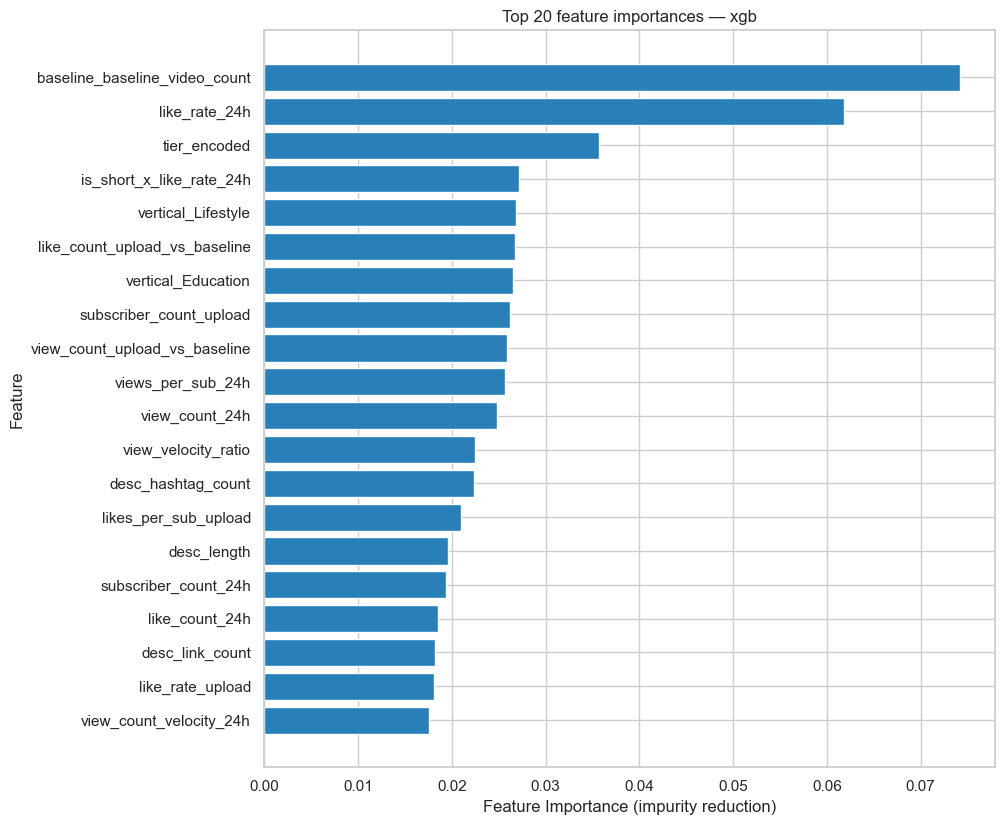

Model 'ensemble_stacking' does not expose feature importances.
Model 'ensemble_voting' does not expose feature importances.
lr_l1:
  like_count_upload_vs_baseline        +11.1883
  view_count_upload_vs_baseline        -2.8818
  like_rate_24h                        +1.1284
  view_count_velocity_24h              -0.8148
  like_velocity_upload                 -0.6028
rf:
  like_rate_24h                        +0.1044
  view_velocity_ratio                  +0.0452
  like_count_upload_vs_baseline        +0.0388
  like_rate_upload                     +0.0364
  duration_seconds                     +0.0304
xgb:
  baseline_baseline_video_count        +0.0742
  like_rate_24h                        +0.0619
  tier_encoded                         +0.0357
  is_short_x_like_rate_24h             +0.0272
  vertical_Lifestyle                   +0.0269
lgb:
  like_count_upload_vs_baseline        +3737.0000
  view_count_upload_vs_baseline        +3442.0000
  like_rate_24h                        +3416.0000

In [21]:
# Top 3 models by test-set AUC — plot feature importance for each.
top3 = sorted(
    run.models.items(),
    key=lambda kv: kv[1]["result"].roc_auc,
    reverse=True,
)[:3]

for model_name, _ in top3:
    result = eda.plot_feature_importance(run, model_name=model_name, top_n=20)
    if result is None:
        continue  # model does not expose feature importances (e.g. stacking ensemble)
    ax, xlabel = result
    ax.set_title(f"Top 20 feature importances — {model_name}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Feature")
    eda.save_fig(ax.figure, fig_path(f"03_feature_importance_{model_name}.png"))
    plt.show()

for name, entry in run.results.items():
    top = entry.get("top_features", [])[:5]
    print(f"{name}:")
    for f in top:
        key = "coefficient" if "coefficient" in f else "importance"
        print(f"  {f['feature']:35s}  {f[key]:+.4f}")

## Cross-version context

Where does this run sit in the project's history? The trajectory plots below load
every saved model snapshot from GCS and chart metric progression across model
generations. The dashed vertical line marks the methodology change at v4.0, when
a locked holdout replaced per-run test sets — comparisons across that line are
directional, not apples-to-apples. (These plots also appear, focused on the
final model, in notebook 05.)

In [22]:
eda.load_model_comparison(run)

Loaded 51 model snapshots


,model_type,data_snapshot,training_date,real_rows,synth_rows,accuracy,roc_auc,precision_macro,recall_macro,f1_macro,precision_above,recall_above,f1_above,precision_below,recall_below,f1_below
version,,,,,,,,,,,,,,,,
v1.0_lr_l1,LogisticRegression,v1.0_model_mixed66,2026-03-26,2100,5000,0.6305,0.6258,0.6258,0.6036,0.5981,0.6366,0.8081,0.7122,0.6149,0.3991,0.4840
v1.0_rf,RandomForest,v1.0_model_mixed66,2026-03-26,2100,5000,0.6952,0.7595,0.6898,0.6848,0.6862,0.7161,0.7643,0.7394,0.6635,0.6053,0.6330
v1.0_xgb,XGBoost,v1.0_model_mixed66,2026-03-26,2100,5000,0.7105,0.7703,0.7066,0.7089,0.7072,0.7562,0.7205,0.7379,0.6570,0.6974,0.6766
v2.0_lr_l1,LogisticRegression,v2.0_mixed_70real,2026-03-26,3255,1743,0.6229,0.6464,0.6153,0.6017,0.5988,0.6360,0.7707,0.6969,0.5946,0.4326,0.5008
v2.0_rf,RandomForest,v2.0_mixed_70real,2026-03-26,3255,1743,0.7334,0.7966,0.7339,0.7197,0.7223,0.7322,0.8297,0.7779,0.7356,0.6096,0.6667
v2.0_xgb,XGBoost,v2.0_mixed_70real,2026-03-26,3255,1743,0.7297,0.7971,0.7267,0.7198,0.7218,0.7409,0.7991,0.7689,0.7125,0.6404,0.6746
v3.0_lr_l1,LogisticRegression,v3.0_mixed_80real,2026-03-28,4037,1261,0.6406,0.6557,0.6399,0.6169,0.6123,0.6416,0.8127,0.7171,0.6382,0.4212,0.5075
v3.0_rf,RandomForest,v3.0_mixed_80real,2026-03-28,4037,1261,0.7604,0.8246,0.7614,0.7491,0.7520,0.7571,0.8428,0.7977,0.7658,0.6554,0.7063
v3.0_xgb,XGBoost,v3.0_mixed_80real,2026-03-28,4037,1261,0.7624,0.8303,0.7592,0.7567,0.7577,0.7791,0.8039,0.7913,0.7394,0.7095,0.7241


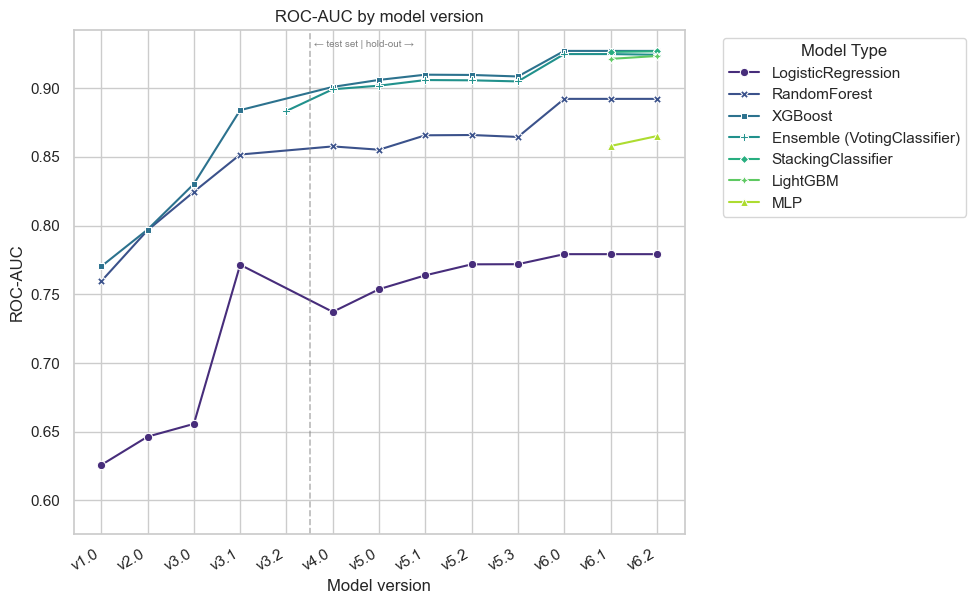

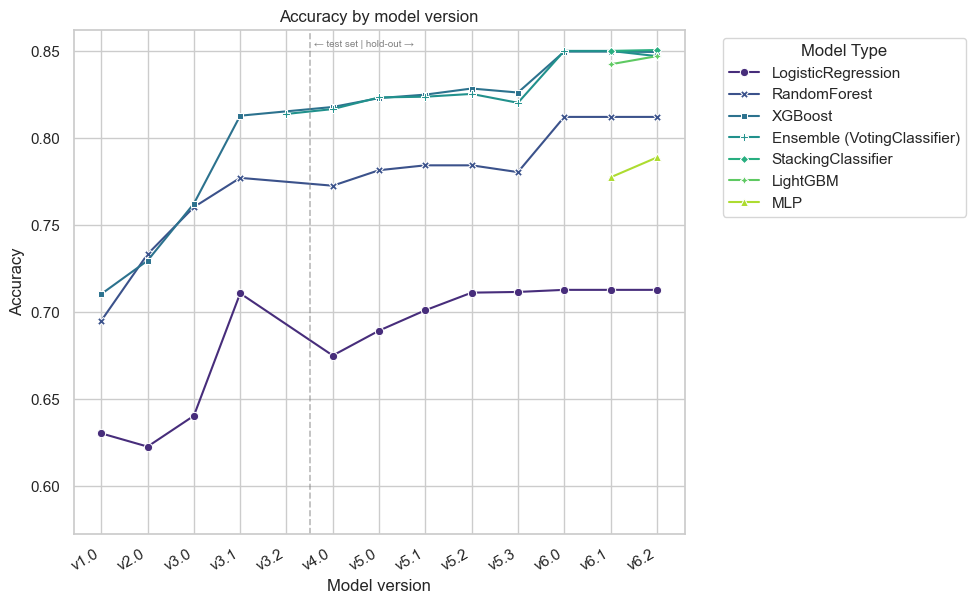

In [23]:
ax = eda.plot_roc_auc(run)
ax.set_title("ROC-AUC by model version")
ax.set_xlabel("Model version")
ax.set_ylabel("ROC-AUC")
eda.save_fig(ax.figure, fig_path("roc_auc_by_version_line.png"))
plt.show()

ax = eda.plot_accuracy(run)
ax.set_title("Accuracy by model version")
ax.set_xlabel("Model version")
ax.set_ylabel("Accuracy")
eda.save_fig(ax.figure, fig_path("accuracy_by_model.png"))
plt.show()

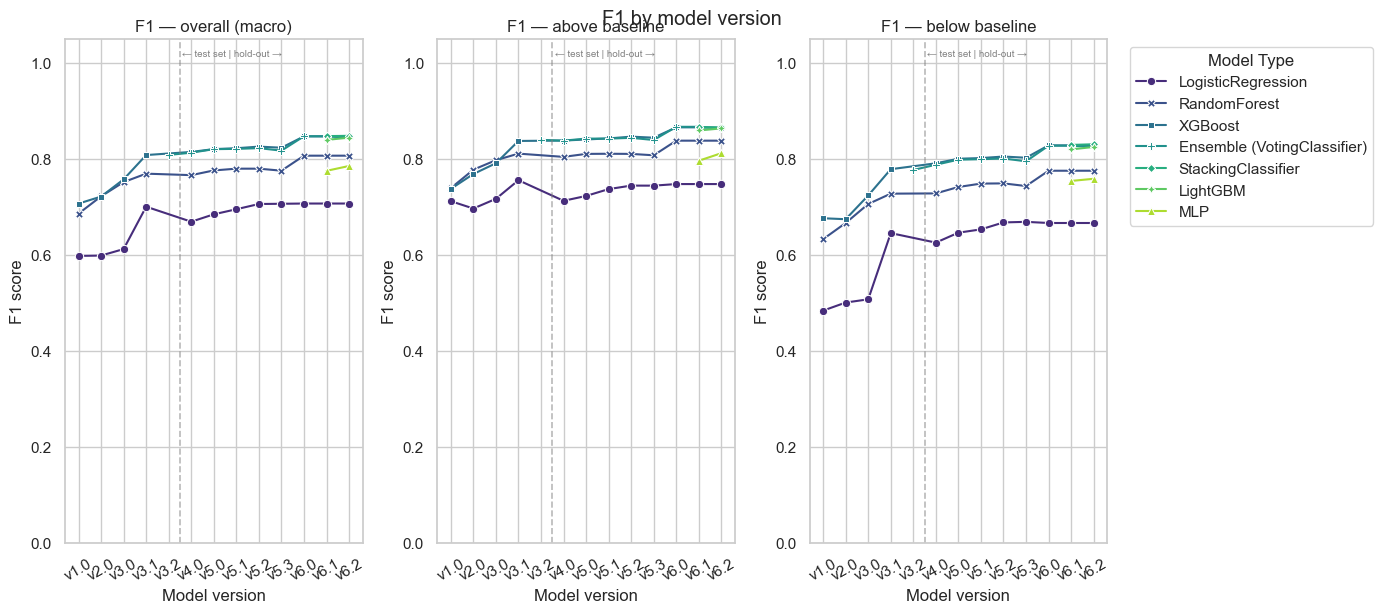

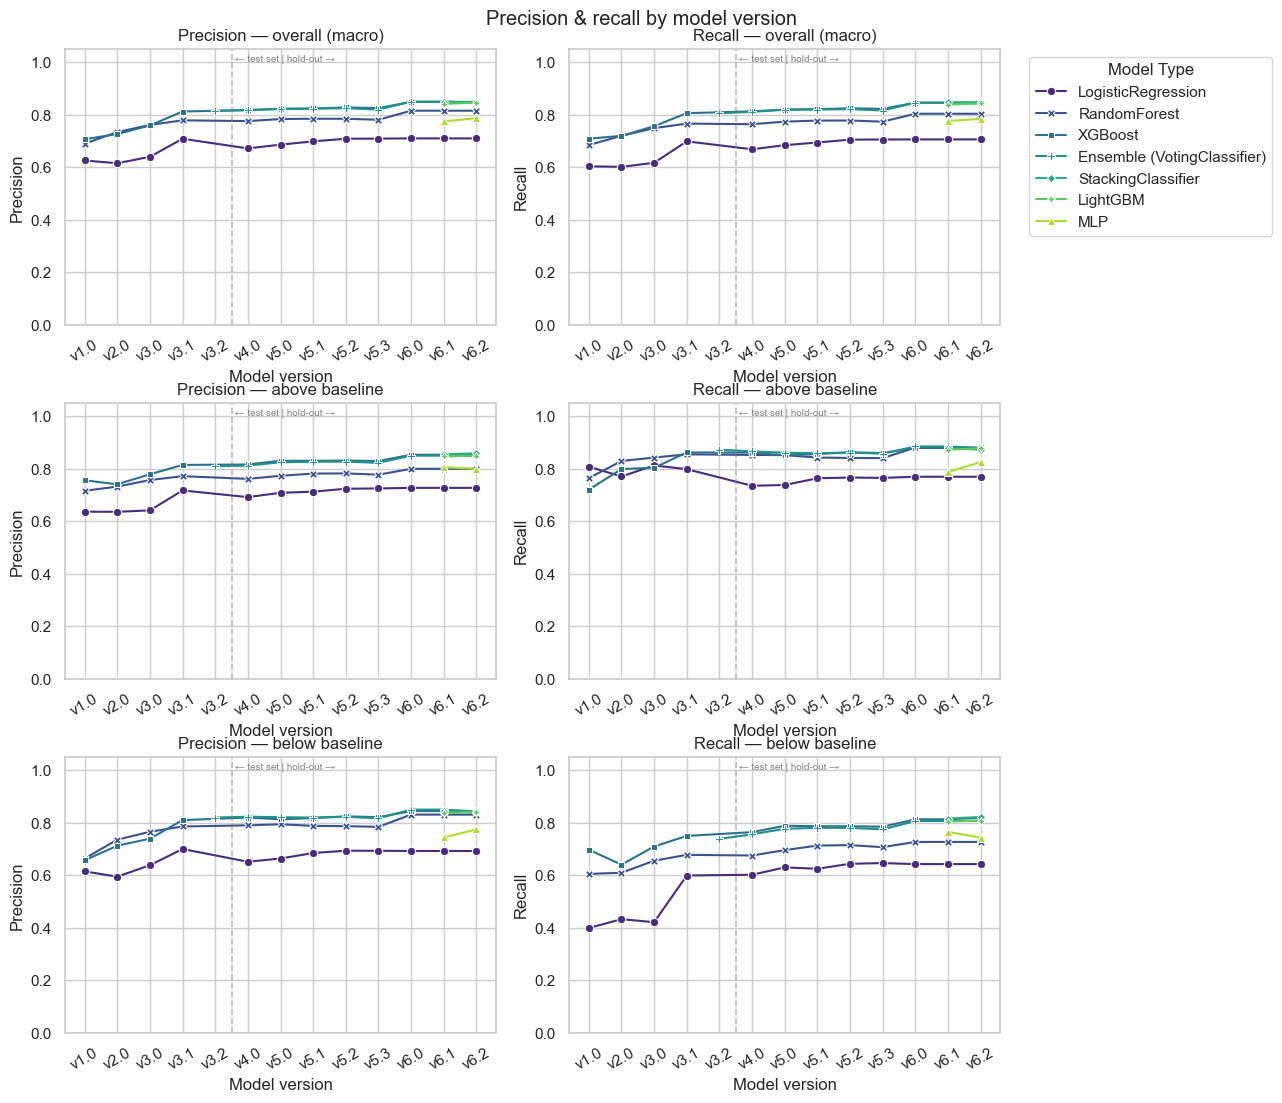

In [24]:
# F1 and precision/recall now lead with the global (macro) panel, then per-class.
fig, axes = eda.plot_f1(run)
f1_titles = ["F1 — overall (macro)", "F1 — above baseline", "F1 — below baseline"]
for ax, title in zip(axes, f1_titles):
    ax.set_title(title)
    ax.set_xlabel("Model version")
    ax.set_ylabel("F1 score")
fig.suptitle("F1 by model version", y=1.02)
eda.save_fig(fig, fig_path("f1_by_model.png"))
plt.show()

fig, axes = eda.plot_precision_recall(run)
pr_titles = [
    "Precision — overall (macro)", "Recall — overall (macro)",
    "Precision — above baseline",  "Recall — above baseline",
    "Precision — below baseline",  "Recall — below baseline",
]
for ax, title in zip(axes.flat, pr_titles):
    ax.set_title(title)
    ax.set_xlabel("Model version")
    ax.set_ylabel(title.split(" ")[0])
fig.suptitle("Precision & recall by model version", y=1.02)
eda.save_fig(fig, fig_path("precision_recall_by_model.png"))
plt.show()

Loaded 51 model snapshots


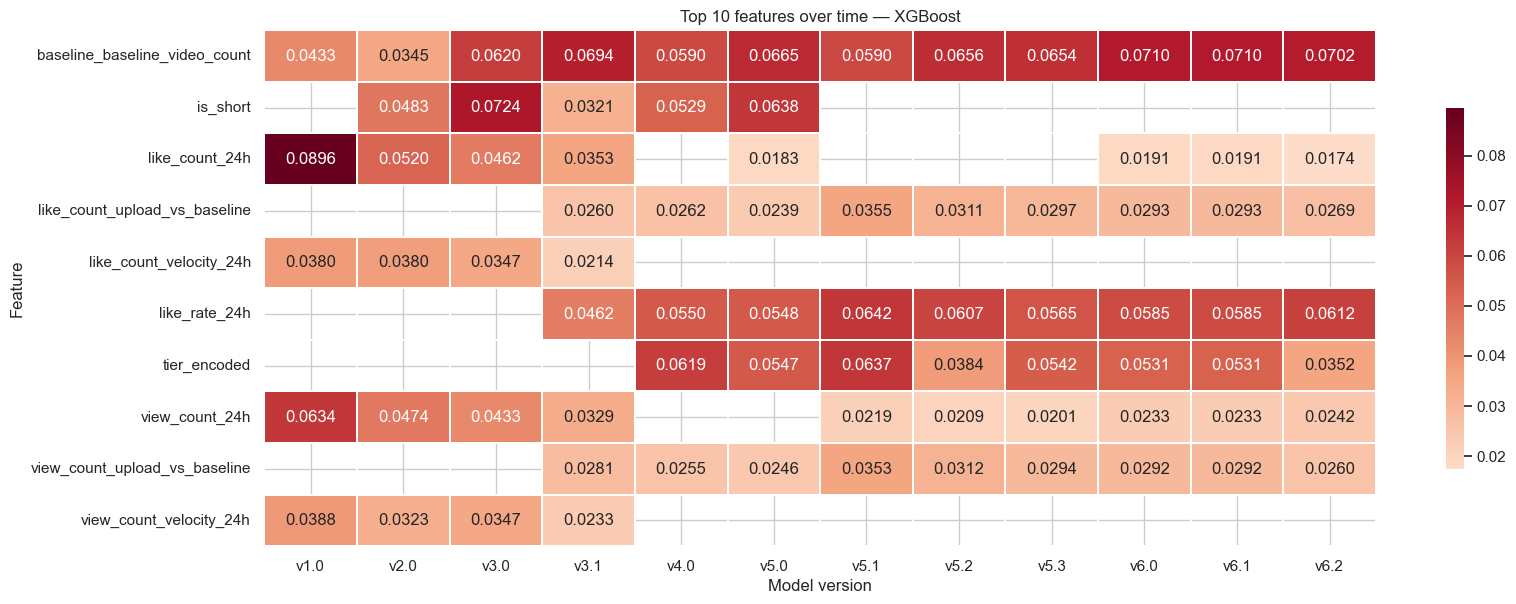

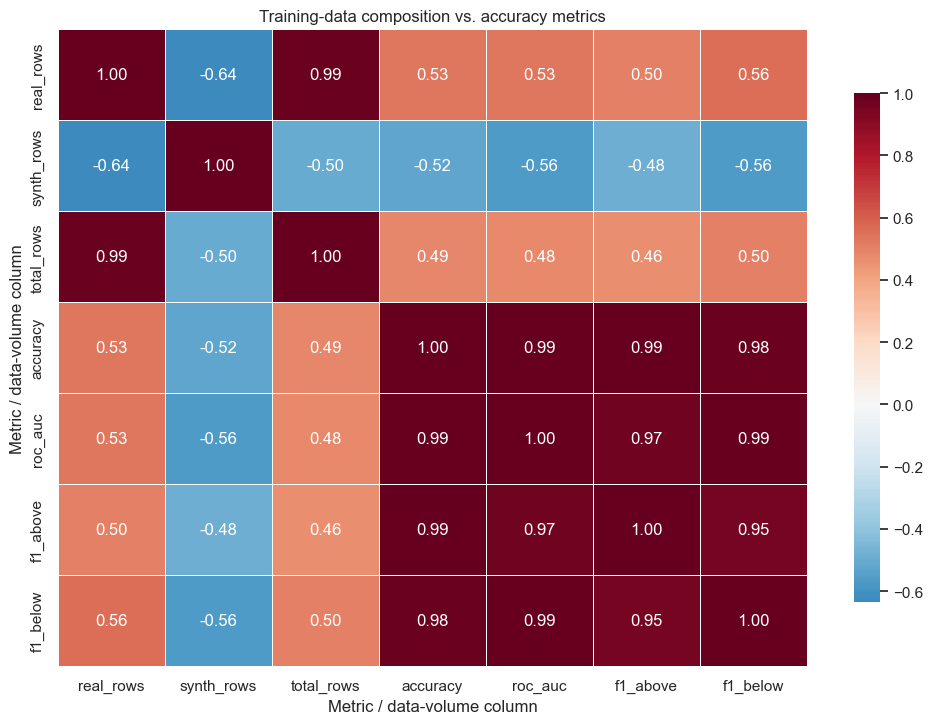

In [25]:
ax = eda.plot_top_features_over_time(run, ModelType.XGB)
ax.set_title("Top 10 features over time — XGBoost")
ax.set_xlabel("Model version")
ax.set_ylabel("Feature")
eda.save_fig(ax.figure, fig_path("features_over_time_xgb.png"))
plt.show()

ax = eda.plot_data_composition_vs_accuracy(run)
ax.set_title("Training-data composition vs. accuracy metrics")
ax.set_xlabel("Metric / data-volume column")
ax.set_ylabel("Metric / data-volume column")
eda.save_fig(ax.figure, fig_path("data_composition_accuracy.png"))
plt.show()

## Findings & next steps

### v6.2 results (data snapshot v3.5_100real — 19,589 train rows)

v6.2 expands the model family from four to seven: LightGBM and MLP join as
independent base models, and a stacking ensemble (RF + XGB + LGB → LR meta,
5-fold CV) is added alongside the existing soft-voting ensemble. XGB, LGB, and
MLP were tuned in notebook 04 (100-iteration random search, 5-fold CV, ROC-AUC
scoring); RF and LR kept their v1.1 snapshot params.

| model | ROC-AUC | accuracy | f1_macro | f1_above | f1_below |
|-------|---------|----------|----------|----------|----------|
| Ensemble stacking (RF+XGB+LGB→LR) | **0.9201** | 0.8428 | 0.8405 | 0.8599 | 0.8210 |
| XGBoost | 0.9200 | 0.8432 | 0.8407 | 0.8606 | 0.8209 |
| LightGBM | 0.9188 | **0.8442** | **0.8416** | **0.8619** | **0.8213** |
| Ensemble voting (RF+XGB 1:2) | 0.9169 | 0.8407 | 0.8379 | 0.8591 | 0.8168 |
| Random Forest | 0.8861 | 0.8062 | 0.8011 | 0.8332 | 0.7689 |
| MLP | 0.8503 | 0.7735 | 0.7703 | 0.7972 | 0.7435 |
| Logistic Regression | 0.7679 | 0.7036 | 0.6982 | 0.7384 | 0.6581 |

#### Model ranking

The top four models (stacking, XGB, LGB, voting) are within 0.003 AUC of each
other — well inside run-to-run noise. Stacking and XGB are effectively tied at
0.920 val AUC (Δ=0.0001). LGB is only 0.001 behind XGB and leads on accuracy and
all F1 metrics at the 0.5 threshold. The voting ensemble trails by 0.003 AUC —
meaningful but small. RF sits ~3.4 AUC points back and is the clear boundary
between the tree-model tier and everything below. MLP (0.850) adds a neural
option but does not approach the tree models. LR is unchanged at 0.768,
consistent with its structural ceiling across all versions.

#### The non-linear gap is structural

The LR → XGB AUC gap is ~0.152. The feature set is dominated by non-linear
signals — velocity ratios, subscriber-normalized engagement rates, tier
interactions, and the `is_short × like_rate_24h` cross — that a linear decision
boundary cannot fully exploit. This gap has been stable from v1.0 through v6.2;
tuning confirmed it does not close with stronger regularization. LR is retained
as an interpretable baseline, not a deployment candidate.

#### XGB vs. LGB vs. stacking

XGB and LGB converge to nearly identical AUC after tuning (0.9200 vs 0.9188,
Δ=0.0012), confirming both gradient-boosting families are capturing the same
underlying signal. Stacking layers a logistic meta-learner over all three tree
models and picks up a negligible 0.0001 AUC above XGB at the cost of
significantly higher training time and inference complexity. The practical
recommendation — further developed in notebook 05 — is XGB for a single
deployable model, with LGB as an equivalent alternative; stacking only if the
marginal AUC edge (essentially zero here) ever justifies the overhead.

#### Segment blind spots

- **Tier S** is the only consistent blind spot: every tree model drops 0.037–0.041
  AUC below its global score (XGB: 0.882 vs 0.920 global; LGB: 0.881 vs 0.919;
  RF: 0.845 vs 0.886). Small channels have lower baseline video counts and noisier
  engagement rates, making normalized signals less stable. The pattern is
  unchanged from v5.x, confirming it is structural rather than a tuning artifact.
- **Vertical** shows no blind spots — Education, Lifestyle, and Tech all stay
  within 0.02 AUC of the global score across every model.

#### Top features

`like_rate_24h` remains the single strongest predictor in XGB, LGB, and RF,
confirming that likes-per-hour at 24 h is the most reliable early momentum
signal. The next tier — `baseline_baseline_video_count`, `tier_encoded`,
baseline-normalized view/like ratios, and `view_velocity_ratio` — reflects
channel scale and context-relative performance rather than raw counts.
`tier_encoded` ranking 3rd in XGB confirms the channel-scale effect is real and
captured. LGB importance rankings mirror XGB closely, reinforcing that both
models are exploiting the same underlying structure.

#### Next steps

- **Final model selection (notebook 05):** XGB and LGB are the primary candidates.
  The Tier S blind spot is the main qualification on any selected model.
- **Tier S gap:** the ~0.038 AUC drop for small channels is the most actionable
  remaining blind spot. Options worth exploring: a lower classification threshold
  for S-tier predictions, or a dedicated S-tier sub-model trained on the S
  segment only.

**Next:** [04 · Hyperparameter tuning](./04_hyperparameter_tuning.ipynb)

## Persist version bump (GCS)

Runs only in the persisting modes (`NEW_MODEL_OLD_DATA` or `NEW_DATA`); a no-op in
`OLD_MODEL_OLD_DATA`.

In [26]:
config.commit()

[dry_run] commit skipped — versions.json not written to GCS.
